# Book Recommendation System Using Machine Learning

## Project Category

Recommendation Systems / Machine Learning

## Objective

The objective of this project is to build a recommendation system that suggests books to users based on user preferences and rating patterns.

This project aims to:

- analyze book rating data,
- identify user preferences,
- build a recommendation engine,
- recommend similar books,
- and explore collaborative filtering techniques.

### Dataset Link
https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset?

## Techniques Used

- Data Cleaning
- Exploratory Data Analysis
- Collaborative Filtering
- Recommendation Systems
- Cosine Similarity
- Matrix Operations

## Libraries Used

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Evaluation Metrics

- Similarity Score
- Recommendation Quality
- User Preference Matching

## Project Workflow

1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis
4. Dataset Merging
5. User-Book Matrix Creation
6. Cosine Similarity Calculation
7. Recommendation Function
8. Book Recommendation Testing
9. Conclusion

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Books.csv to Books.csv
Saving Ratings.csv to Ratings.csv
Saving Users.csv to Users.csv


In [3]:
import pandas as pd

books = pd.read_csv(
    "Books.csv",
    encoding="latin-1",
    low_memory=False)

ratings = pd.read_csv(
    "Ratings.csv",
    encoding="latin-1",
    low_memory=False)

users = pd.read_csv(
    "Users.csv",
    encoding="latin-1",
    low_memory=False)

In [4]:
print("Books:", books.shape)

print("Ratings:", ratings.shape)

print("Users:", users.shape)

Books: (271360, 8)
Ratings: (1149780, 3)
Users: (278858, 3)


In [5]:
books.head()


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [6]:
books.sample(5)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
117540,0091777496,Book of Life,Gould,1993,Trafalgar Square Publishing,http://images.amazon.com/images/P/0091777496.0...,http://images.amazon.com/images/P/0091777496.0...,http://images.amazon.com/images/P/0091777496.0...
208461,0396069924,Murder on Board: Including \the Mystery of the...,Agatha Christie,1974,Dodd Mead,http://images.amazon.com/images/P/0396069924.0...,http://images.amazon.com/images/P/0396069924.0...,http://images.amazon.com/images/P/0396069924.0...
252903,0802110495,Crisis: Heterosexual Behavior in the Age of AIDS,William H. Masters,1988,Pub Group West,http://images.amazon.com/images/P/0802110495.0...,http://images.amazon.com/images/P/0802110495.0...,http://images.amazon.com/images/P/0802110495.0...
30757,0312992416,Kiss of the Night (A Dark-Hunter Novel),Sherrilyn Kenyon,2004,St. Martin's Paperbacks,http://images.amazon.com/images/P/0312992416.0...,http://images.amazon.com/images/P/0312992416.0...,http://images.amazon.com/images/P/0312992416.0...
74177,2869433972,Le Visiteur,Eric-Emmanuel Schmitt,1998,Actes sud-Papiers,http://images.amazon.com/images/P/2869433972.0...,http://images.amazon.com/images/P/2869433972.0...,http://images.amazon.com/images/P/2869433972.0...


In [7]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [8]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [9]:
print(books.columns)

print(ratings.columns)

print(users.columns)

Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
       'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
      dtype='object')
Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='object')
Index(['User-ID', 'Location', 'Age'], dtype='object')


In [10]:
users["Age"].isnull().sum()

np.int64(110762)

In [12]:
users.isnull().sum()

,0
User-ID,0
Location,0
Age,110762


In [14]:
books.isnull().sum()

,0
ISBN,0
Book-Title,0
Book-Author,2
Year-Of-Publication,0
Publisher,2
Image-URL-S,0
Image-URL-M,0
Image-URL-L,3


In [15]:
books = books.dropna()

In [16]:
ratings.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0


In [17]:
merged_df = ratings.merge(books,on="ISBN")

merged_df.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...


In [18]:
print("Merged Dataset Shape:", merged_df.shape)

print("\nColumns:")
print(merged_df.columns)

print("\nMissing Values:")
print(merged_df.isnull().sum())

Merged Dataset Shape: (1031128, 10)

Columns:
Index(['User-ID', 'ISBN', 'Book-Rating', 'Book-Title', 'Book-Author',
       'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M',
       'Image-URL-L'],
      dtype='object')

Missing Values:
User-ID                0
ISBN                   0
Book-Rating            0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64


In [19]:
book_ratings = merged_df[[
        "User-ID",
        "Book-Title",
        "Book-Rating"]]

book_ratings.head()

,User-ID,Book-Title,Book-Rating
0,276725,Flesh Tones: A Novel,0
1,276726,Rites of Passage,5
2,276727,The Notebook,0
3,276729,Help!: Level 1,3
4,276729,The Amsterdam Connection : Level 4 (Cambridge ...,6


In [20]:
rating_counts = book_ratings.groupby("Book-Title")["Book-Rating"].count().reset_index()

rating_counts.columns = ["Book-Title","Rating_Count"]

rating_counts = rating_counts.sort_values(by="Rating_Count",ascending=False)

rating_counts.head(10)

,Book-Title,Rating_Count
234945,Wild Animus,2502
196321,The Lovely Bones: A Novel,1295
183568,The Da Vinci Code,898
5303,A Painted House,838
199232,The Nanny Diaries: A Novel,828
27921,Bridget Jones's Diary,815
206497,The Secret Life of Bees,774
52980,Divine Secrets of the Ya-Ya Sisterhood: A Novel,740
204382,The Red Tent (Bestselling Backlist),723
14391,Angels &amp; Demons,670


In [21]:
average_ratings = book_ratings.groupby("Book-Title")["Book-Rating"].mean().reset_index()

average_ratings.columns = ["Book-Title","Average_Rating"]

average_ratings.head()

,Book-Title,Average_Rating
0,A Light in the Storm: The Civil War Diary of ...,2.25
1,Always Have Popsicles,0.00
2,Apple Magic (The Collector's series),0.00
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.00
4,Beyond IBM: Leadership Marketing and Finance ...,0.00


In [22]:
popular_books = rating_counts.merge(average_ratings, on="Book-Title")

popular_books = popular_books.sort_values(by="Rating_Count",ascending=False)

popular_books.head(10)

,Book-Title,Rating_Count,Average_Rating
0,Wild Animus,2502,1.019584
1,The Lovely Bones: A Novel,1295,4.468726
2,The Da Vinci Code,898,4.642539
3,A Painted House,838,3.231504
4,The Nanny Diaries: A Novel,828,3.530193
5,Bridget Jones's Diary,815,3.527607
6,The Secret Life of Bees,774,4.447028
7,Divine Secrets of the Ya-Ya Sisterhood: A Novel,740,3.437838
8,The Red Tent (Bestselling Backlist),723,4.334716
9,Angels &amp; Demons,670,3.708955


In [23]:
popular_books = popular_books[
    popular_books["Rating_Count"] >= 50]

popular_books.shape

(2444, 3)

In [24]:
filtered_ratings = book_ratings[
    book_ratings["Book-Title"].isin(popular_books["Book-Title"])]

filtered_ratings.shape

(288740, 3)

In [25]:
user_book_matrix = filtered_ratings.pivot_table(
    index="Book-Title",
    columns="User-ID",
    values="Book-Rating")

user_book_matrix = user_book_matrix.fillna(0)

user_book_matrix.head()

User-ID,8,9,14,16,17,19,23,26,32,39,...,278820,278824,278828,278832,278836,278843,278844,278846,278851,278854
Book-Title,,,,,,,,,,,,,,,,,,,,,
10 Lb. Penalty,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16 Lighthouse Road,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1984,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010: Odyssey Two,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(user_book_matrix)

print(similarity_scores.shape)

(2444, 2444)


In [27]:
def recommend_books(book_name):

    index = user_book_matrix.index.get_loc( book_name)

    distances = similarity_scores[index]

    similar_books = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1])[1:11]

    for i in similar_books:

        print(user_book_matrix.index[i[0]])

In [28]:
recommend_books("1984")

Animal Farm
Brave New World
American Psycho (Vintage Contemporaries)
Slaughterhouse Five or the Children's Crusade: A Duty Dance With Death
Lying Awake
Lord of the Flies
The Vampire Lestat (Vampire Chronicles, Book II)
The Catcher in the Rye
The Restaurant at the End of the Universe (Hitchhiker's Trilogy (Paperback))
Roll of Thunder, Hear My Cry


In [29]:
def recommend_books_with_scores(book_name):

    index = user_book_matrix.index.get_loc(book_name)

    distances = similarity_scores[index]

    similar_books = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1])[1:11]

    recommendations = []

    for i, score in similar_books:
        recommendations.append([
            user_book_matrix.index[i],
            score])

    return pd.DataFrame(
        recommendations,
        columns=["Recommended Book", "Similarity Score"] )

In [30]:
recommend_books_with_scores("1984")

,Recommended Book,Similarity Score
0,Animal Farm,0.150133
1,Brave New World,0.122630
2,American Psycho (Vintage Contemporaries),0.088027
3,Slaughterhouse Five or the Children's Crusade:...,0.083888
4,Lying Awake,0.083781
5,Lord of the Flies,0.083779
6,"The Vampire Lestat (Vampire Chronicles, Book II)",0.081705
7,The Catcher in the Rye,0.081183
8,The Restaurant at the End of the Universe (Hit...,0.076138
9,"Roll of Thunder, Hear My Cry",0.074309


In [31]:
user_book_matrix.index[:30]

Index(['10 Lb. Penalty', '16 Lighthouse Road', '1984', '1st to Die: A Novel',
       '2010: Odyssey Two', '204 Rosewood Lane', '2061: Odyssey Three',
       '24 Hours', '2nd Chance', '3rd Degree', '4 Blondes',
       '50 Simple Things You Can Do to Save the Earth',
       '84 Charing Cross Road',
       'A 2nd Helping of Chicken Soup for the Soul (Chicken Soup for the Soul Series (Paper))',
       'A Beautiful Mind: The Life of Mathematical Genius and Nobel Laureate John Nash',
       'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Clockwork Orange (Norton Paperback Fiction)',
       'A Cold Heart (Alex Delaware Novels (Paperback))',
       'A Cold Heart: An Alex Delaware Novel', 'A Confederacy of Dunces',
       'A Confederacy of Dunces (Evergreen Book)', 'A Cry In The Night',
       'A Cup of Tea (Ballantine Reader's Circle)', 'A Dangerous Fortune',
       'A Darkness More Than Night', 'A Day Late and

In [32]:
recommend_books_with_scores("Animal Farm")

,Recommended Book,Similarity Score
0,1984,0.150133
1,The Green Mile: The Mouse on the Mile (Green M...,0.106264
2,The Green Mile: The Bad Death of Eduard Delacr...,0.102600
3,Brave New World,0.099323
4,Hamlet,0.097622
5,Lord of the Flies,0.092978
6,Macbeth,0.089518
7,The Green Mile: Coffey on the Mile (Green Mile...,0.086006
8,The Chocolate War (Laurel Leaf Books),0.083208
9,Adventures of Huckleberry Finn,0.083160


In [33]:
recommend_books_with_scores("The Da Vinci Code")

,Recommended Book,Similarity Score
0,Angels &amp; Demons,0.172633
1,Digital Fortress : A Thriller,0.096715
2,Middlesex: A Novel,0.095165
3,The Lovely Bones: A Novel,0.085404
4,The Secret Life of Bees,0.084091
5,No Second Chance,0.076110
6,Touching Evil,0.073133
7,"Dude, Where's My Country?",0.072069
8,The Sweet Potato Queens' Book of Love,0.070806
9,Nights in Rodanthe,0.069968


In [34]:
recommend_books_with_scores("Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))")

,Recommended Book,Similarity Score
0,Harry Potter and the Chamber of Secrets (Book 2),0.303517
1,Harry Potter and the Prisoner of Azkaban (Book 3),0.258462
2,Harry Potter and the Goblet of Fire (Book 4),0.220296
3,Harry Potter and the Order of the Phoenix (Boo...,0.145328
4,Anne of Ingleside (Anne of Green Gables Novels...,0.085137
5,"Word Freak: Heartbreak, Triumph, Genius, and O...",0.076162
6,Secrets,0.075685
7,Anne of Avonlea (Anne of Green Gables Novels (...,0.074183
8,The Fellowship of the Ring (The Lord of the Ri...,0.074075
9,Like Water for Chocolate: A Novel in Monthly I...,0.070552


In [35]:
user_book_matrix[user_book_matrix.index.str.contains("Harry Potter", case=False)].index

Index(['Harry Potter and the Chamber of Secrets (Book 2)',
       'Harry Potter and the Goblet of Fire (Book 4)',
       'Harry Potter and the Order of the Phoenix (Book 5)',
       'Harry Potter and the Prisoner of Azkaban (Book 3)',
       'Harry Potter and the Sorcerer's Stone (Book 1)',
       'Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))'],
      dtype='object', name='Book-Title')

/tmp/ipykernel_8982/2396868862.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


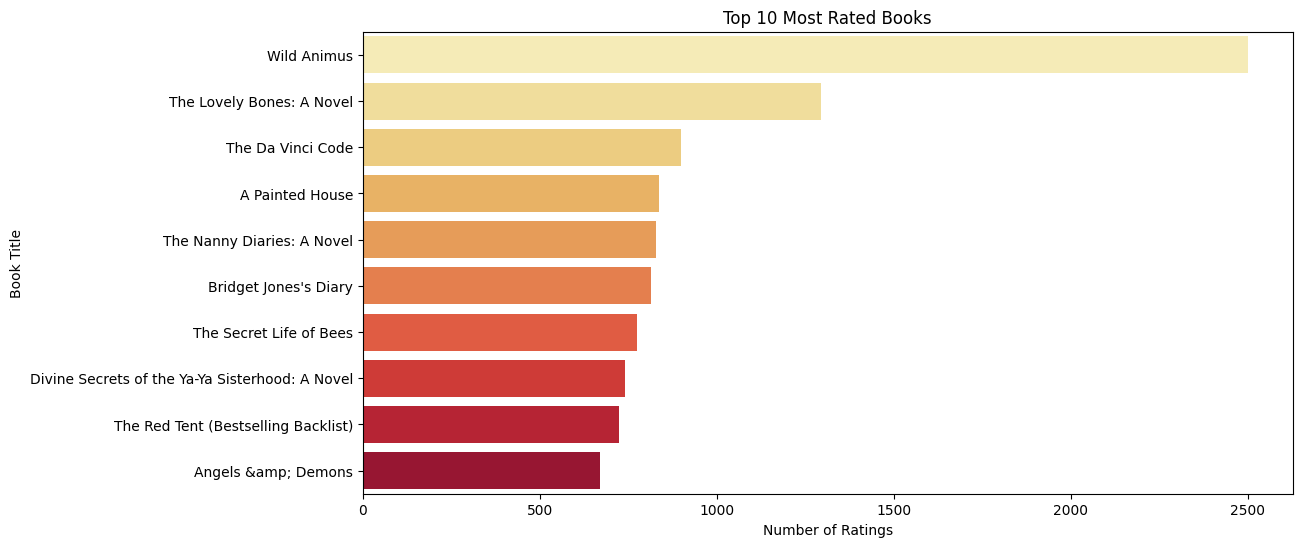

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

top_books = popular_books.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_books,
    x="Rating_Count",
    y="Book-Title",
    palette="YlOrRd")

plt.title("Top 10 Most Rated Books")
plt.xlabel("Number of Ratings")
plt.ylabel("Book Title")

plt.show()

In [38]:
recommend_books_with_scores("1984")

,Recommended Book,Similarity Score
0,Animal Farm,0.150133
1,Brave New World,0.122630
2,American Psycho (Vintage Contemporaries),0.088027
3,Slaughterhouse Five or the Children's Crusade:...,0.083888
4,Lying Awake,0.083781
5,Lord of the Flies,0.083779
6,"The Vampire Lestat (Vampire Chronicles, Book II)",0.081705
7,The Catcher in the Rye,0.081183
8,The Restaurant at the End of the Universe (Hit...,0.076138
9,"Roll of Thunder, Hear My Cry",0.074309


In [39]:
user_book_matrix[
    user_book_matrix.index.str.contains(
        "Harry Potter",
        case=False )].index

Index(['Harry Potter and the Chamber of Secrets (Book 2)',
       'Harry Potter and the Goblet of Fire (Book 4)',
       'Harry Potter and the Order of the Phoenix (Book 5)',
       'Harry Potter and the Prisoner of Azkaban (Book 3)',
       'Harry Potter and the Sorcerer's Stone (Book 1)',
       'Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))'],
      dtype='object', name='Book-Title')

## Recommendation System Results

The book recommendation system successfully generated similar book suggestions based on user rating behavior.

These results are meaningful because the recommended books share similar literary and thematic characteristics.

The system used collaborative filtering and cosine similarity to identify books with similar user rating patterns.